# Task 2: Basic ML Models — Customer Churn Prediction
**Models:** Logistic Regression | Random Forest | XGBoost

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             roc_auc_score, roc_curve, confusion_matrix)
from xgboost import XGBClassifier
import warnings; 
warnings.filterwarnings("ignore")

df = pd.read_csv("../data/telco_churn.csv")
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].fillna(df["MonthlyCharges"], inplace=True)
df.drop("customerID", axis=1, inplace=True)
le = LabelEncoder()
for col in df.select_dtypes("object").columns.drop("Churn"):
    df[col] = le.fit_transform(df[col])
df["Churn"] = (df["Churn"] == "Yes").astype(int)

X = df.drop("Churn", axis=1)
y = df["Churn"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
Xtr_s = scaler.fit_transform(X_train); 
Xte_s = scaler.transform(X_test)
print(f"Train: {X_train.shape} | Test: {X_test.shape} | Churn rate: {y.mean()*100:.1f}%")

Train: (5634, 19) | Test: (1409, 19) | Churn rate: 26.5%


## Train 3 Models

In [7]:
lr  = LogisticRegression(max_iter=1000, random_state=42, C=0.1).fit(Xtr_s, y_train)
rf  = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1).fit(X_train, y_train)
xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric="logloss",
                     use_label_encoder=False, learning_rate=0.1).fit(X_train, y_train)
print("All 3 models trained!")

All 3 models trained!


## Compare Metrics

In [8]:
results = []
for name, model, Xte, Xtr, ytr in [
    ("Logistic Regression", lr, Xte_s, Xtr_s, y_train),
    ("Random Forest",       rf, X_test, X_train, y_train),
    ("XGBoost",            xgb, X_test, X_train, y_train),
]:
    yp = model.predict(Xte); 
    ypr = model.predict_proba(Xte)[:,1]
    yptr = model.predict(Xtr)
    results.append({
        "Model": name,
        "Train Acc": round(accuracy_score(ytr, yptr)*100,2),
        "Test Acc":  round(accuracy_score(y_test, yp)*100,2),
        "F1":        round(f1_score(y_test, yp)*100,2),
        "AUC-ROC":   round(roc_auc_score(y_test, ypr)*100,2),
    })

rdf = pd.DataFrame(results)
print(rdf.to_string(index=False))
print("\nNote: High (Train vs Test) gap = overfitting (check RF!)")

              Model  Train Acc  Test Acc    F1  AUC-ROC
Logistic Regression      80.49     79.99 59.01    83.91
      Random Forest      99.80     79.56 57.01    82.37
            XGBoost      87.11     79.35 57.02    83.52

Note: High (Train vs Test) gap = overfitting (check RF!)


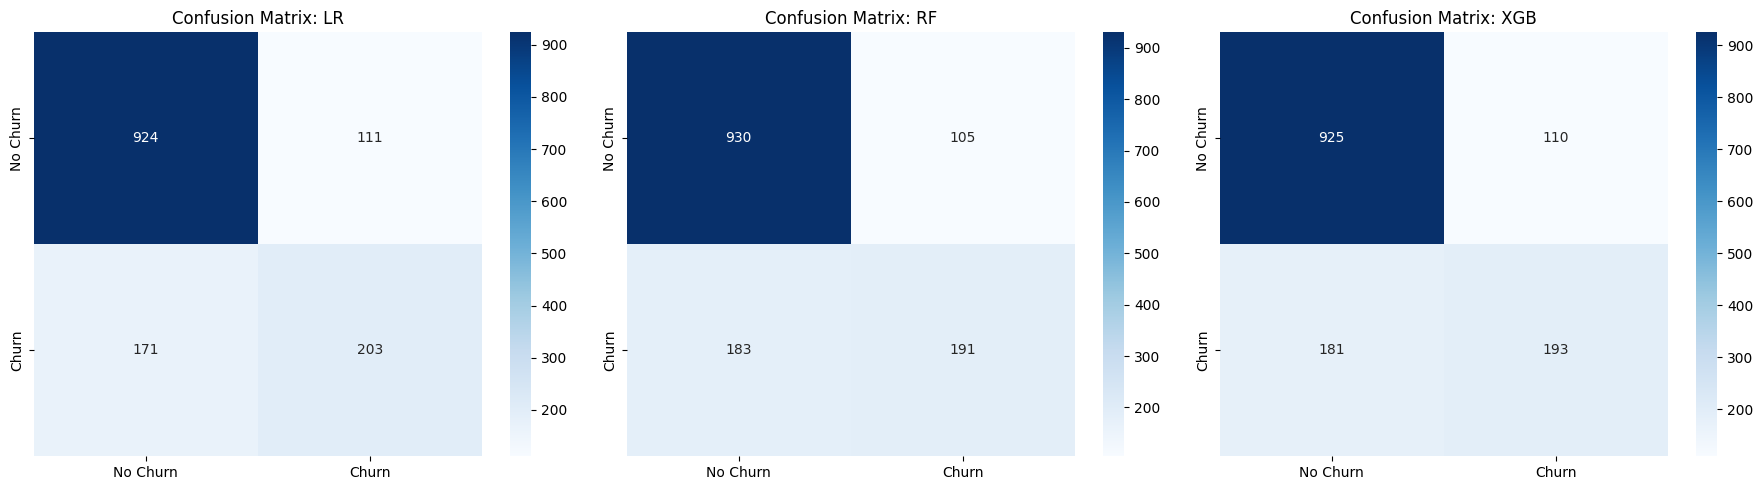

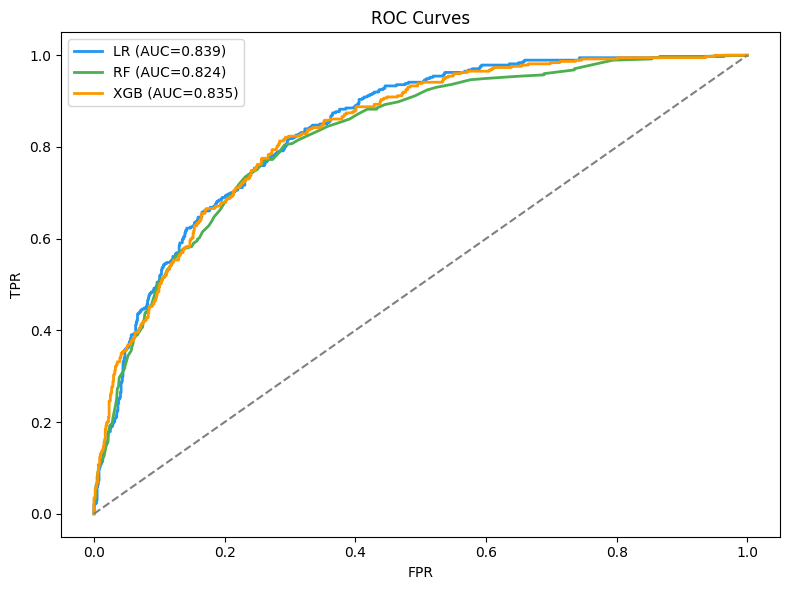

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ["#2196F3","#4CAF50","#FF9800"]
models_info = [("LR", lr, Xte_s), ("RF", rf, X_test), ("XGB", xgb, X_test)]

# Confusion matrices
for i, (name, model, Xte) in enumerate(models_info):
    cm = confusion_matrix(y_test, model.predict(Xte))
    sns.heatmap(cm, annot=True, fmt="d", ax=axes[i], cmap="Blues",
                xticklabels=["No Churn","Churn"], yticklabels=["No Churn","Churn"])
    axes[i].set_title(f"Confusion Matrix: {name}")
plt.tight_layout()
plt.savefig("../slides/confusion_matrices.png", dpi=100, bbox_inches="tight")
plt.show()

# ROC Curves
plt.figure(figsize=(8,6))
for name, model, Xte, color in [
    ("LR", lr, Xte_s, "#2196F3"), ("RF", rf, X_test, "#4CAF50"), ("XGB", xgb, X_test, "#FF9800")]:
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(Xte)[:,1])
    plt.plot(fpr, tpr, lw=2, color=color, label=f"{name} (AUC={roc_auc_score(y_test, model.predict_proba(Xte)[:,1]):.3f})")
plt.plot([0,1],[0,1],"--",color="gray"); plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("ROC Curves"); plt.legend(); plt.tight_layout()
plt.savefig("../slides/roc_curves.png", dpi=100, bbox_inches="tight")
plt.show()

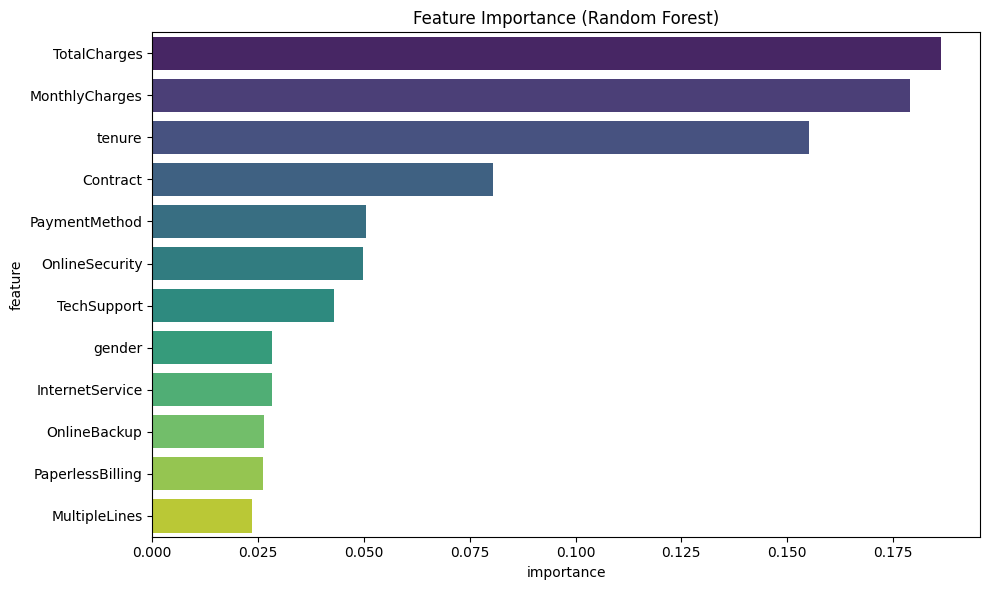


Best Model: XGBoost
Better AUC-ROC -> better at separating churners from non-churners
Gradient Boosting = learns from previous mistakes iteratively
Built-in regularization -> low variance, avoids overfitting  
No feature scaling needed (robust to outliers)
Handles mixed data types better than Logistic Regression

Bias-Variance Tradeoff:
  LR:  High Bias, Low Variance  -> underfits complex patterns
  RF:  Low Bias, High Variance  -> can overfit (train vs test gap)
  XGB: Balanced via boosting    -> best generalization 



In [10]:
# Feature Importance
fi = pd.DataFrame({"feature":X.columns,"importance":rf.feature_importances_}).sort_values("importance",ascending=False).head(12)
plt.figure(figsize=(10,6))
sns.barplot(data=fi, y="feature", x="importance", palette="viridis")
plt.title("Feature Importance (Random Forest)"); plt.tight_layout()
plt.savefig("../slides/feature_importance.png", dpi=100, bbox_inches="tight")
plt.show()

print("""
Best Model: XGBoost
Better AUC-ROC -> better at separating churners from non-churners
Gradient Boosting = learns from previous mistakes iteratively
Built-in regularization -> low variance, avoids overfitting  
No feature scaling needed (robust to outliers)
Handles mixed data types better than Logistic Regression

Bias-Variance Tradeoff:
  LR:  High Bias, Low Variance  -> underfits complex patterns
  RF:  Low Bias, High Variance  -> can overfit (train vs test gap)
  XGB: Balanced via boosting    -> best generalization 
""")